<h1 style="color:#FF5733; font-size:35px;">1. Importing Libraries</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

<h1 style="color:#FF5733; font-size:35px;">2. Loading the dataset</h1>

In [3]:
dataset_Chennai = pd.read_csv("Zomato Chennai Listing 2020.csv")
dataset_Chennai.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


<h1 style="color:#FF5733; font-size:35px;">3. Dataset Information</h1>

In [4]:
dataset_Chennai.info()
dataset_Chennai.shape
dataset_Chennai.columns

<class 'pandas.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  str    
 1   Name of Restaurant     12032 non-null  str    
 2   Address                12032 non-null  str    
 3   Location               12032 non-null  str    
 4   Cuisine                12032 non-null  str    
 5   Top Dishes             12032 non-null  str    
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  str    
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  str    
 11  Features               12032 non-null  str    
dtypes: float64(3), str(9)
memory usage: 1.1 MB


Index(['Zomato URL', 'Name of Restaurant', 'Address', 'Location', 'Cuisine',
       'Top Dishes', 'Price for 2', 'Dining Rating', 'Dining Rating Count',
       'Delivery Rating', 'Delivery Rating Count', 'Features'],
      dtype='str')

<h1 style="color:#FF5733; font-size:35px;">4. Checking the Missing Values</h1>

In [6]:
dataset_Chennai.isnull().sum()

Zomato URL                  0
Name of Restaurant          0
Address                     0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

<h1 style="color:#FF5733; font-size:35px;">5. Data Cleaning: Converting numerical columns</h1>

In [7]:
dataset_Chennai["Price for 2"] = pd.to_numeric(dataset_Chennai["Price for 2"], errors="coerce")

dataset_Chennai["Dining Rating"] = pd.to_numeric(dataset_Chennai["Dining Rating"], errors="coerce")

dataset_Chennai["Delivery Rating"] = pd.to_numeric(dataset_Chennai["Delivery Rating"], errors="coerce")

dataset_Chennai["Dining Rating Count"] = pd.to_numeric(dataset_Chennai["Dining Rating Count"], errors="coerce")

dataset_Chennai["Delivery Rating Count"] = pd.to_numeric(dataset_Chennai["Delivery Rating Count"], errors="coerce")

<h1 style="color:#FF5733; font-size:35px;">6. Handling Missing Values</h1>

In [8]:
dataset_Chennai["Dining Rating"] = dataset_Chennai["Dining Rating"].fillna(0)

dataset_Chennai["Dining Rating Count"] = dataset_Chennai["Dining Rating Count"].fillna(0)

dataset_Chennai["Delivery Rating"] = dataset_Chennai["Delivery Rating"].fillna(0)

dataset_Chennai["Delivery Rating Count"] = dataset_Chennai["Delivery Rating Count"].fillna(0)

<h1 style="color:#FF5733; font-size:35px;">7. Converting Count Columns to Integer</h1>

In [9]:
dataset_Chennai["Dining Rating Count"] = dataset_Chennai["Dining Rating Count"].astype(int)

dataset_Chennai["Delivery Rating Count"] = dataset_Chennai["Delivery Rating Count"].astype(int)

<h1 style="color:#FF5733; font-size:35px;">8. Checking the Duplicate Data</h1>

In [10]:
dataset_Chennai.duplicated().sum()

np.int64(0)

<h1 style="color:#FF5733; font-size:35px;">9. Reset Index</h1>

In [11]:
dataset_Chennai.reset_index(drop=True, inplace=True)

<h1 style="color:#FF5733; font-size:35px;">10. Exploratory Data Analysis (EDA)</h1>

In [12]:
location_df = dataset_Chennai["Location"].value_counts().reset_index()

location_df.columns = ["Location", "Restaurant Count"]

location_df.head()

,Location,Restaurant Count
0,Porur,418
1,Velachery,372
2,Ambattur,334
3,T. Nagar,315
4,Perungudi,288


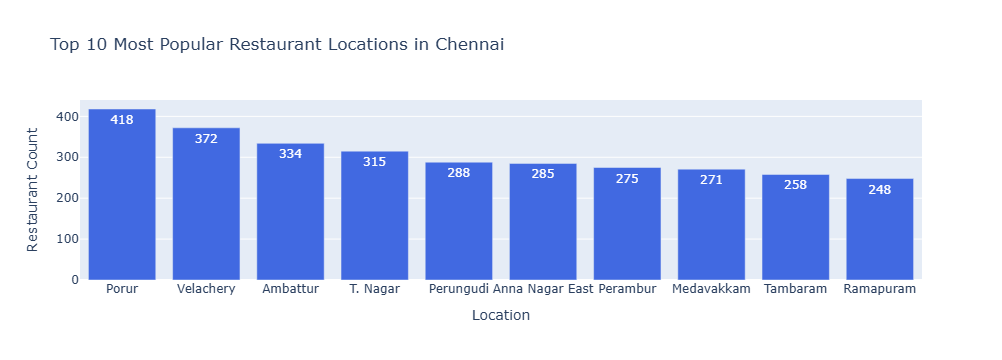

In [37]:
px.bar(
    location_count.sort_values("Restaurant Count", ascending=False),
    x="Location",
    y="Restaurant Count",
    text="Restaurant Count",
    color_discrete_sequence=["royalblue"],
    title="Top 10 Most Popular Restaurant Locations in Chennai"
).show()

<h1 style="color:#FF5733; font-size:35px;">11. Top Cuisine Types</h1>

In [14]:
cuisine_df = dataset_Chennai["Cuisine"].value_counts().reset_index()

cuisine_df.columns = ["Cuisine", "Count"]

cuisine_df.head()

,Cuisine,Count
0,['South Indian'],883
1,['Fast Food'],295
2,['Bakery'],266
3,"['South Indian', ' Chinese']",233
4,['Biryani'],225


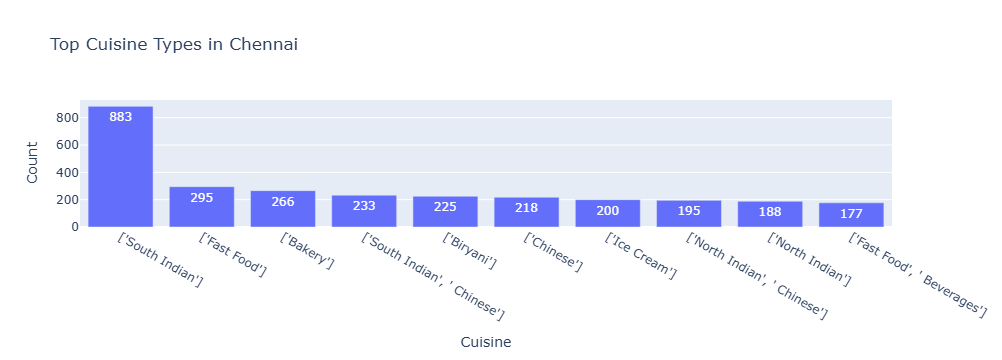

In [39]:
fig = px.bar(
    cuisine_df.head(10),
    x="Cuisine",
    y="Count",
    text="Count",
    title="Top Cuisine Types in Chennai"
)

fig.show()

<h1 style="color:#FF5733; font-size:35px;">12. Dining Rating Distribution</h1>

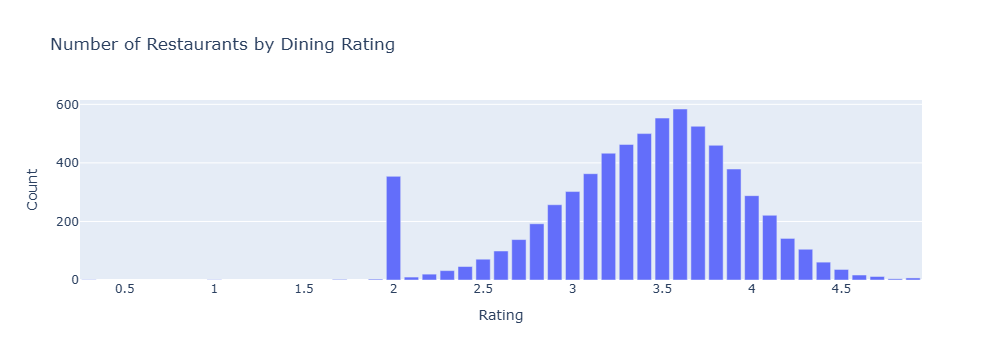

In [19]:
rating_count = rating_df["Dining Rating"].value_counts().sort_index().reset_index()

rating_count.columns = ["Rating","Count"]

fig = px.bar(rating_count, x="Rating", y="Count",
             title="Number of Restaurants by Dining Rating")

fig.show()

<h1 style="color:#FF5733; font-size:35px;">13. Delivery Rating Distribution</h1>

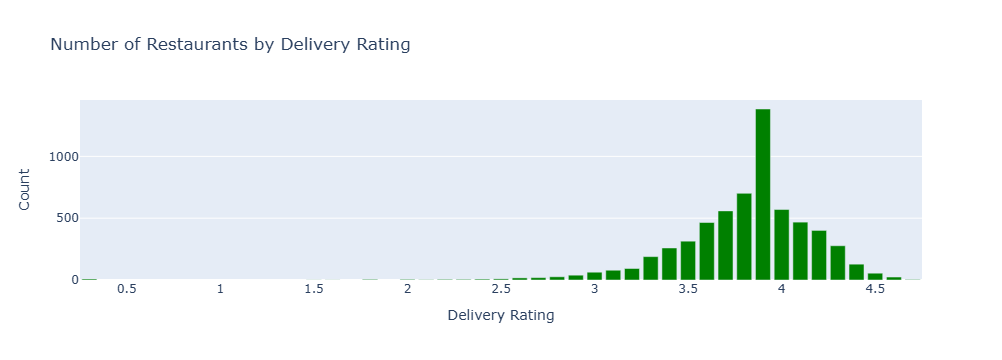

In [21]:
px.bar(
    dataset_Chennai[dataset_Chennai["Delivery Rating"] > 0]["Delivery Rating"]
    .value_counts()
    .sort_index()
    .reset_index(name="Count")
    .rename(columns={"index": "Delivery Rating"}),
    x="Delivery Rating",
    y="Count",
    title="Number of Restaurants by Delivery Rating",
    color_discrete_sequence=["green"]
).show()

<h1 style="color:#FF5733; font-size:35px;">14. Price vs Dining Rating</h1>

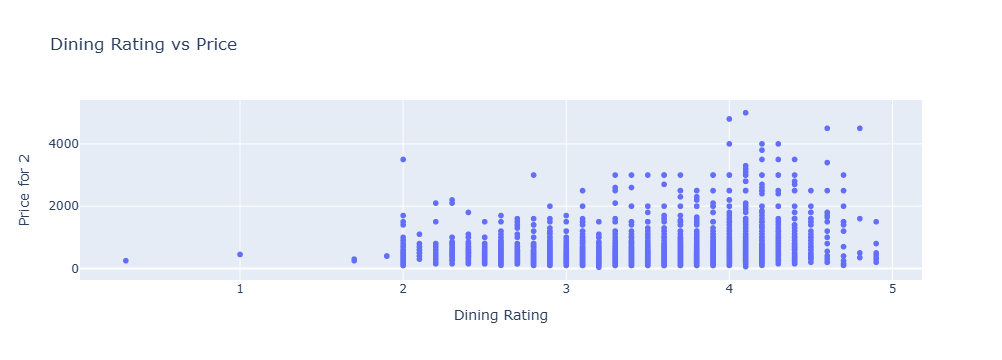

In [23]:
fig = px.scatter(
    dataset_Chennai[dataset_Chennai["Dining Rating"] > 0],
    x="Dining Rating",
    y="Price for 2",
    title="Dining Rating vs Price"
)

fig.show()

<h1 style="color:#FF5733; font-size:35px;">15. Average Price by Location</h1>

In [24]:
price_location = dataset_Chennai.groupby("Location")["Price for 2"].mean().reset_index()

price_location.head()

,Location,Price for 2
0,InterContinental Chennai Mahabalipuram Resort...,1500.000000
1,Abhiramapuram,228.571429
2,"Abu Sarovar Portico, Egmore",1000.000000
3,Adambakkam,291.025641
4,Adyar,443.550000


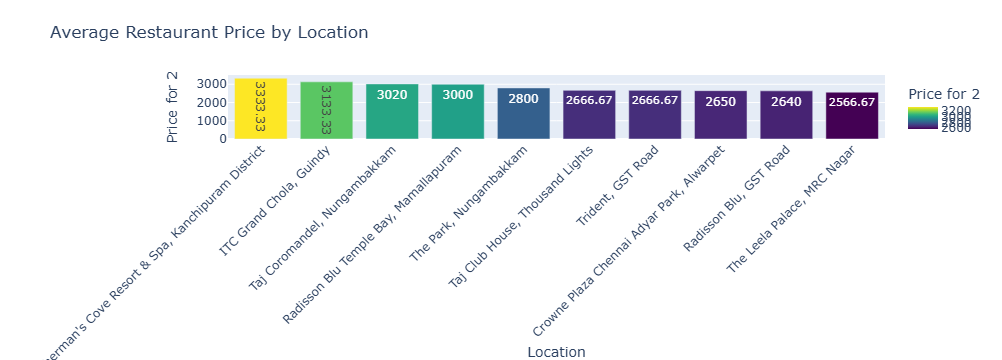

In [27]:
price_location["Price for 2"] = price_location["Price for 2"].round(2)

fig = px.bar(
    price_location.sort_values("Price for 2", ascending=False).head(10),
    x="Location",
    y="Price for 2",
    text="Price for 2",
    color="Price for 2",
    color_continuous_scale="viridis",
    title="Average Restaurant Price by Location"
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

<h1 style="color:#FF5733; font-size:35px;">16. Top Rated Restaurants</h1>

In [28]:
top_restaurants = dataset_Chennai.sort_values("Dining Rating", ascending=False).head(10)

top_restaurants[["Name of Restaurant","Location","Dining Rating"]]

,Name of Restaurant,Location,Dining Rating
184,Gossip Fusion Bistro,Kanathur,4.9
57,Brownie Heaven,Royapettah,4.9
105,Bhangra,"Mayajaal Multiplex, Kanathur",4.9
219,Prems Graama Bhojanam,Adyar,4.9
320,Bombay Kulfi,Adyar,4.9
192,Kabab Corner,Egmore,4.9
155,The Sandwich Shop,West Mambalam,4.9
195,The Marina,Nungambakkam,4.8
443,Avartana - ITC Grand Chola,"ITC Grand Chola, Guindy",4.8
163,Momo Sa-Khang by Kailash Kitchen,Choolaimedu,4.8


<h1 style="color:#FF5733; font-size:35px;">17. Top 10 Most Expensive Restaurant Locations</h1>

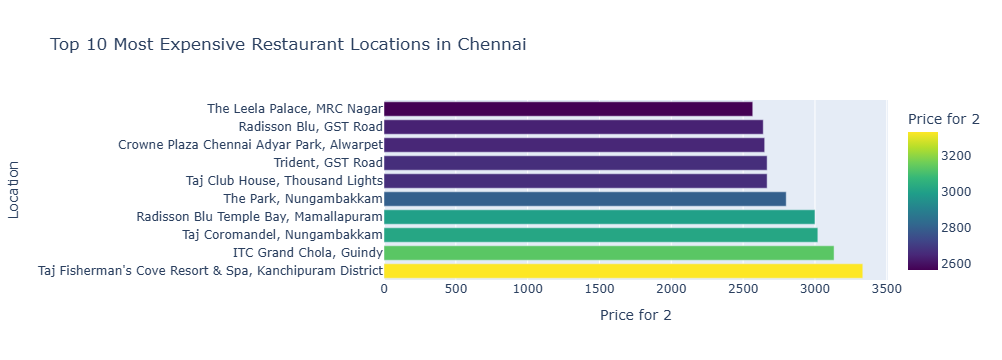

In [30]:
price_location["Price for 2"] = price_location["Price for 2"].round(0)

px.bar(
    price_location.sort_values("Price for 2", ascending=False).head(10),
    x="Price for 2",
    y="Location",
    orientation="h",
    color="Price for 2",
    color_continuous_scale="viridis",
    title="Top 10 Most Expensive Restaurant Locations in Chennai"
).show()

<h1 style="color:#FF5733; font-size:35px;">18. Dining Rating vs Delivery Rating</h1>

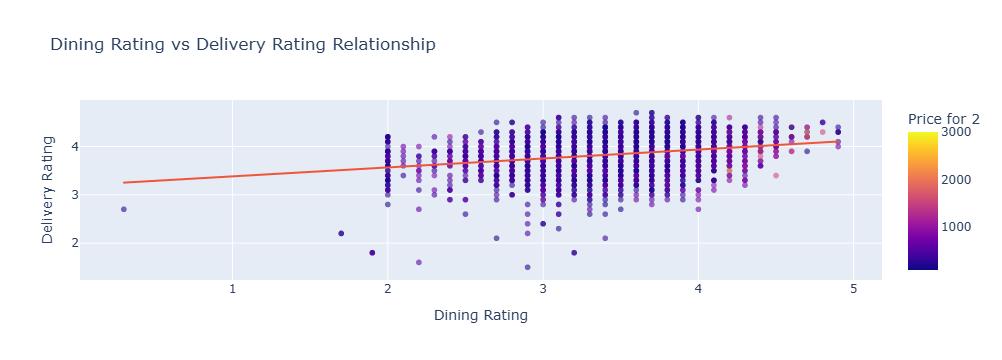

In [33]:
px.scatter(
    dataset_Chennai[
        (dataset_Chennai["Dining Rating"] > 0) &
        (dataset_Chennai["Delivery Rating"] > 0)
    ],
    x="Dining Rating",
    y="Delivery Rating",
    color="Price for 2",
    opacity=0.6,
    trendline="ols",
    color_continuous_scale="plasma",
    title="Dining Rating vs Delivery Rating Relationship"
).show()